# GAN

## create pictures of trips

In [1]:
import os
import matplotlib.pyplot as plt
from time import time
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import groupby
import netCDF4
from scipy.sparse import dok_matrix

In [2]:
class Grid:
    def __init__(self, lon, lat):
        
        self.lon = lon
        self.lat = lat[::-1]
        
        self.height = len(self.lat)
        self.width = len(self.lat)
        
        self.size = (len(lat), len(lon))
        
        self.grid = np.array([[(lon, lat) for lon in self.lon] for lat in self.lat])
        self.grid_lon = np.array([[lon for lon in self.lon] for lat in self.lat])
        self.grid_lat = np.array([[lat for lon in self.lon] for lat in self.lat])
               
        self.feature = {}
        
        self.trajs = {}
        
    
    # UTILS ----------------------------------------     
    def coord2idx(self, coord):
        return (np.argmin(abs(self.lat - coord[1])), np.argmin(abs(self.lon - coord[0])))
        
    def idx2coord(self, idx):
        return self.grid[idx]

     # ADDING TRAJECTORY ----------------------------------------   
    def add_trajectory(self, time, traj, name):
        # get position on grid
        state = [(np.argmin(abs(self.lat - traj[i,1])), np.argmin(abs(self.lon - traj[i,0]))) 
                 for i in range(traj.shape[0])]
        
        # group identical consecutive states
        grouped_state = [(k, sum(1 for i in j)) for k,j in groupby(state)]
        
        traj_new = [grouped_state[i][0] for i in range(len(grouped_state))]
        
        ## check if start = end
        if traj_new[0] == traj_new[-1] and len(traj_new)>2:
            ## continuous
            if np.max(abs(np.array(traj_new[1:len(traj_new)]) - np.array(traj_new[0:len(traj_new)-1])))<=1:
                self.trajs[name] = traj_new
                
    def show_trajectory(self, name):
        grid = 0*self.grid_lon
        for step in self.trajs[name]:
            grid[step[0], step[1]] += 1
        return grid
    
    def show_trajectory_all(self):
        grid = 0*self.grid_lon
        for k,v in self.trajs.items():
            for step in v:
                grid[step[0], step[1]] += 1
        return grid
        
    # ADDING FEATURE MAPS ----------------------------------------
    def format_feature(self, x, y, data):
        feature = np.zeros(self.size)

        xx = np.array([[self.lat[np.argmin(abs(self.lat - i))] for j in y] for i in x])
        yy = np.array([[self.lon[np.argmin(abs(self.lon - j))] for j in y] for i in x])

        for i in range(len(self.lat)):
            for j in range(len(self.lon)):
                feature[i,j] = np.mean(data[(yy == self.lon[j]) * (xx == self.lat[i])])
                
        return feature
    
    def normalize_feature(self):
        for key,value in self.feature.items():
            self.feature[key] = (value - np.max(value)) / (np.max(value) - np.min(value))
            
            
    def add_feature(self, x, y, data, name):
        self.feature[name] = self.format_feature(x,y,data)
        
    def show_feature(self, name):   
        plt.imshow(self.feature[name])
        plt.show()

    def show_feature_all(self):   
        fig, axs = plt.subplots(1,len(self.feature))
        i = 0
        for k in self.feature.keys():
            axs[i].imshow(self.feature[k])
            i += 1
        plt.show()

In [ ]:
conn = sqlite3.connect('/home/amdroy/MEGA/DATA/seabirdbank.db')
request = "SELECT DISTINCT  bird.id as bird, trip.id as trip, gps.datetime, gps.lon, gps.lat FROM gps \
INNER JOIN trip ON gps.trip = trip.id \
INNER JOIN bird ON trip.bird = bird.id \
WHERE substr(bird.fieldwork,1,1) = 'P' \
AND bird.species = 'SV'"

df = pd.read_sql_query(request, conn)
df = df.set_index("trip", drop = False)

grid = Grid(np.arange(-78, -77, 0.037), np.arange(-12.4, -11.4, 0.037))

im_traj = []
for trip in np.unique(df.index.values):
    t = df.loc[trip,"datetime"].values
    traj = df.loc[trip,"lon":"lat"].values
    
    grid.add_trajectory(t, traj,trip)
    
    # new_plt
    if trip in grid.trajs.keys():
        
        im = grid.show_trajectory(trip)
        im = im/5
        
        im_traj.append(im)
        
        plt.imshow(im)
        plt.savefig('./data/trajectory/'+trip)
    

In [7]:
# class TrajDataset(torch.utils.data.Dataset):
#     def __init__(self, data, transforms=None):
#         super().__init__()
#         self.data = data
#         self.transforms = transforms
            
#     def __getitem__(self, idx):
#         data = self.data[idx]
#         if self.transforms:
#             data = self.transforms(data)
#         return data
    
#     def __len__(self):
#         return (len(self.data))
    
# # define transforms
# transform = tv.transforms.Compose(
#     [tv.transforms.ToTensor(),
#      tv.transforms.Normalize((0.5, ), (0.5, ))
# ])

# dataset = TrajDataset(im_traj, transform)

In [23]:
batch_size = 32
epochs = 100
latent_dim = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = [torch.tensor([im], dtype = torch.float) for im in im_traj]

dataloader = DataLoader(dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=1,
        drop_last=True
        )

noise_fn = lambda x: torch.randn((x, latent_dim), device=device)

In [24]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, batchnorm=True):
        """A generator for mapping a latent space to a sample space.
        The sample space for this generator is single-channel, 28x28 images
        with pixel intensity ranging from -1 to +1.
        Args:
            latent_dim (int): latent dimension ("noise vector")
            batchnorm (bool): Whether or not to use batch normalization
        """
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        self.batchnorm = batchnorm
        self._init_modules()

    def _init_modules(self):
        """Initialize the modules."""
        # Project the input
        self.linear1 = nn.Linear(self.latent_dim, 256*7*7, bias=False)
        self.bn1d1 = nn.BatchNorm1d(256*7*7) if self.batchnorm else None
        self.leaky_relu = nn.LeakyReLU()

        # Convolutions
        self.conv1 = nn.Conv2d(
                in_channels=256,
                out_channels=128,
                kernel_size=5,
                stride=1,
                padding=2,
                bias=False)
        self.bn2d1 = nn.BatchNorm2d(128) if self.batchnorm else None

        self.conv2 = nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False)
        self.bn2d2 = nn.BatchNorm2d(64) if self.batchnorm else None

        self.conv3 = nn.ConvTranspose2d(
                in_channels=64,
                out_channels=1,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False)
        self.tanh = nn.Tanh()

    def forward(self, input_tensor):
        """Forward pass; map latent vectors to samples."""
        intermediate = self.linear1(input_tensor)
        intermediate = self.bn1d1(intermediate)
        intermediate = self.leaky_relu(intermediate)

        intermediate = intermediate.view((-1, 256, 7, 7))

        intermediate = self.conv1(intermediate)
        if self.batchnorm:
            intermediate = self.bn2d1(intermediate)
        intermediate = self.leaky_relu(intermediate)

        intermediate = self.conv2(intermediate)
        if self.batchnorm:
            intermediate = self.bn2d2(intermediate)
        intermediate = self.leaky_relu(intermediate)

        intermediate = self.conv3(intermediate)
        output_tensor = self.tanh(intermediate)
        return output_tensor

In [25]:
g = Generator(latent_dim, batchnorm=True)
noise = noise_fn(latent_dim)

In [26]:
generated = g(noise)
generated.shape

torch.Size([16, 1, 28, 28])

In [27]:
class Discriminator(nn.Module):
    def __init__(self):
        """A discriminator for discerning real from generated images.
        Images must be single-channel and 28x28 pixels.
        Output activation is Sigmoid.
        """
        super(Discriminator, self).__init__()
        self._init_modules()

    def _init_modules(self):
        """Initialize the modules."""
        self.conv1 = nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=5,
                stride=2,
                padding=2,
                bias=True)
        self.leaky_relu = nn.LeakyReLU()
        self.dropout_2d = nn.Dropout2d(0.3)

        self.conv2 = nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                stride=2,
                padding=2,
                bias=True)

        self.linear1 = nn.Linear(128*7*7, 1, bias=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_tensor):
        """Forward pass; map samples to confidence they are real [0, 1]."""
        intermediate = self.conv1(input_tensor)
        intermediate = self.leaky_relu(intermediate)
        intermediate = self.dropout_2d(intermediate)

        intermediate = self.conv2(intermediate)
        intermediate = self.leaky_relu(intermediate)
        intermediate = self.dropout_2d(intermediate)

        intermediate = intermediate.view((-1, 128*7*7))
        intermediate = self.linear1(intermediate)
        output_tensor = self.sigmoid(intermediate)

        return output_tensor

In [28]:
d = Discriminator()

In [29]:
d.forward(generated)

tensor([[0.4602],
        [0.4740],
        [0.4658],
        [0.4466],
        [0.4660],
        [0.4906],
        [0.4875],
        [0.4785],
        [0.4876],
        [0.4733],
        [0.4667],
        [0.4562],
        [0.4514],
        [0.5058],
        [0.4877],
        [0.4467]], grad_fn=<SigmoidBackward>)

In [30]:
for batch, real_samples in enumerate(dataloader):
        real_samples = real_samples.to(device)

In [31]:
generated.shape

torch.Size([16, 1, 28, 28])

In [32]:
real_samples.shape

torch.Size([32, 1, 28, 28])

In [33]:
d(real_samples)

tensor([[0.4922],
        [0.4839],
        [0.4893],
        [0.4986],
        [0.4972],
        [0.4859],
        [0.4877],
        [0.4868],
        [0.4831],
        [0.4867],
        [0.4855],
        [0.4882],
        [0.4821],
        [0.4972],
        [0.4866],
        [0.4958],
        [0.4921],
        [0.4930],
        [0.4865],
        [0.4956],
        [0.4831],
        [0.4872],
        [0.4929],
        [0.4801],
        [0.4909],
        [0.4944],
        [0.4760],
        [0.4864],
        [0.4923],
        [0.4936],
        [0.4953],
        [0.4920]], grad_fn=<SigmoidBackward>)

In [34]:
class DCGAN():
    def __init__(self, latent_dim, noise_fn, dataloader,
                 batch_size=3, device='cpu', lr_d=1e-3, lr_g=2e-4):
        """A very basic DCGAN class for generating MNIST digits
        Args:
            generator: a Ganerator network
            discriminator: A Discriminator network
            noise_fn: function f(num: int) -> pytorch tensor, (latent vectors)
            dataloader: a pytorch dataloader for loading images
            batch_size: training batch size. Must match that of dataloader
            device: cpu or CUDA
            lr_d: learning rate for the discriminator
            lr_g: learning rate for the generator
        """
        self.generator = Generator(latent_dim).to(device)
        self.discriminator = Discriminator().to(device)
        self.noise_fn = noise_fn
        self.dataloader = dataloader
        self.batch_size = batch_size
        self.device = device
        self.criterion = nn.BCELoss()
        self.optim_d = optim.Adam(self.discriminator.parameters(),
                                  lr=lr_d, betas=(0.5, 0.999))
        self.optim_g = optim.Adam(self.generator.parameters(),
                                  lr=lr_g, betas=(0.5, 0.999))
        self.target_ones = torch.ones((batch_size, 1), device=device)
        self.target_zeros = torch.zeros((batch_size, 1), device=device)

    def generate_samples(self, latent_vec=None, num=None):
        """Sample images from the generator.
        Images are returned as a 4D tensor of values between -1 and 1.
        Dimensions are (number, channels, height, width). Returns the tensor
        on cpu.
        Args:
            latent_vec: A pytorch latent vector or None
            num: The number of samples to generate if latent_vec is None
        If latent_vec and num are None then use self.batch_size
        random latent vectors.
        """
        num = self.batch_size if num is None else num
        latent_vec = self.noise_fn(num) if latent_vec is None else latent_vec
        with torch.no_grad():
            samples = self.generator(latent_vec)
        samples = samples.cpu()  # move images to cpu
        return samples

    def train_step_generator(self):
        """Train the generator one step and return the loss."""
        self.generator.zero_grad()

        latent_vec = self.noise_fn(self.batch_size)
        generated = self.generator(latent_vec)
        classifications = self.discriminator(generated)
        loss = self.criterion(classifications, self.target_ones)
        loss.backward()
        self.optim_g.step()
        return loss.item()

    def train_step_discriminator(self, real_samples):
        """Train the discriminator one step and return the losses."""
        self.discriminator.zero_grad()

        # real samples
        pred_real = self.discriminator(real_samples)
        loss_real = self.criterion(pred_real, self.target_ones)

        # generated samples
        latent_vec = self.noise_fn(self.batch_size)
        with torch.no_grad():
            fake_samples = self.generator(latent_vec)
        pred_fake = self.discriminator(fake_samples)
        loss_fake = self.criterion(pred_fake, self.target_zeros)

        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        self.optim_d.step()
        return loss_real.item(), loss_fake.item()

    def train_epoch(self, print_frequency=10, max_steps=0):
        """Train both networks for one epoch and return the losses.
        Args:
            print_frequency (int): print stats every `print_frequency` steps.
            max_steps (int): End epoch after `max_steps` steps, or set to 0
                             to do the full epoch.
        """
        loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
        for batch, real_samples in enumerate(self.dataloader):
            real_samples = real_samples.to(self.device)
            ldr_, ldf_ = self.train_step_discriminator(real_samples)
            loss_d_real_running += ldr_
            loss_d_fake_running += ldf_
            loss_g_running += self.train_step_generator()
            if print_frequency and (batch+1) % print_frequency == 0:
                print(f"{batch+1}/{len(self.dataloader)}:"
                      f" G={loss_g_running / (batch+1):.3f},"
                      f" Dr={loss_d_real_running / (batch+1):.3f},"
                      f" Df={loss_d_fake_running / (batch+1):.3f}",
                      end='\r',
                      flush=True)
            if max_steps and batch == max_steps:
                break
        if print_frequency:
            print()
        loss_g_running /= batch
        loss_d_real_running /= batch
        loss_d_fake_running /= batch
        return (loss_g_running, (loss_d_real_running, loss_d_fake_running))

In [35]:
gan = DCGAN(latent_dim, noise_fn, dataloader, device=device, batch_size=batch_size)
start = time()

In [36]:
for i in range(epochs):
    print(f"Epoch {i+1}; Elapsed time = {int(time() - start)}s")
    gan.train_epoch()

Epoch 1; Elapsed time = 0s
10/15: G=4.817, Dr=0.417, Df=0.165
Epoch 2; Elapsed time = 2s
10/15: G=12.092, Dr=0.036, Df=0.039
Epoch 3; Elapsed time = 4s
10/15: G=9.623, Dr=0.147, Df=0.023
Epoch 4; Elapsed time = 5s
10/15: G=8.909, Dr=0.213, Df=0.009
Epoch 5; Elapsed time = 7s
10/15: G=10.719, Dr=0.185, Df=0.009
Epoch 6; Elapsed time = 8s
10/15: G=10.091, Dr=0.003, Df=0.002
Epoch 7; Elapsed time = 10s
10/15: G=10.241, Dr=0.452, Df=0.001
Epoch 8; Elapsed time = 11s
10/15: G=10.448, Dr=0.410, Df=0.001
Epoch 9; Elapsed time = 13s
10/15: G=10.405, Dr=0.513, Df=0.001
Epoch 10; Elapsed time = 14s
10/15: G=10.559, Dr=0.096, Df=0.001
Epoch 11; Elapsed time = 16s
10/15: G=14.212, Dr=0.041, Df=0.023
Epoch 12; Elapsed time = 18s
10/15: G=12.023, Dr=0.564, Df=0.198
Epoch 13; Elapsed time = 19s
10/15: G=9.454, Dr=0.020, Df=0.022
Epoch 14; Elapsed time = 21s
10/15: G=9.020, Dr=0.013, Df=0.023
Epoch 15; Elapsed time = 23s
10/15: G=15.157, Dr=0.035, Df=0.028
Epoch 16; Elapsed time = 24s
10/15: G=12.776,

In [37]:
images = gan.generate_samples()

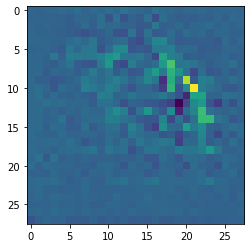

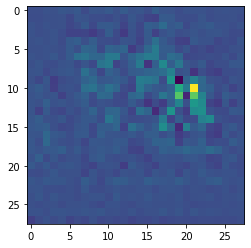

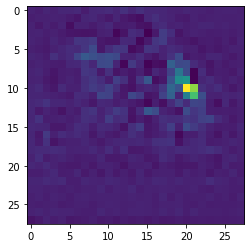

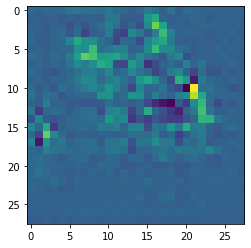

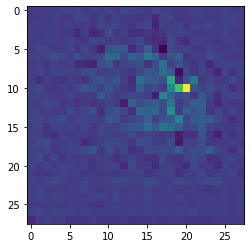

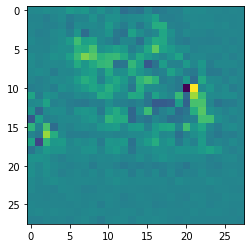

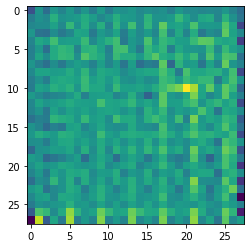

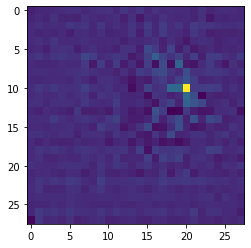

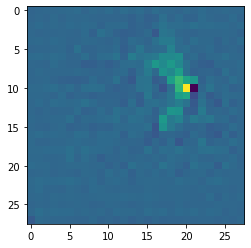

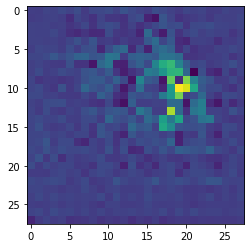

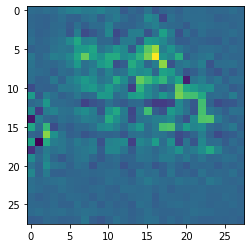

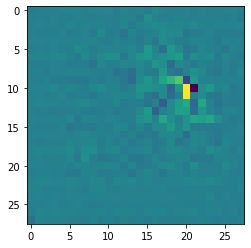

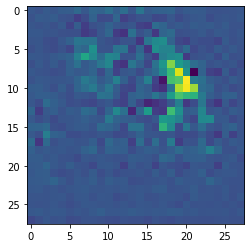

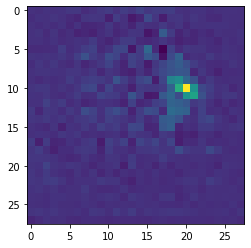

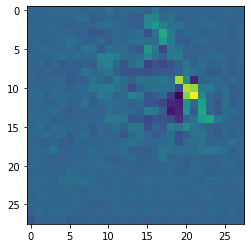

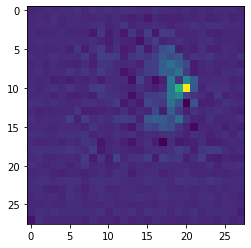

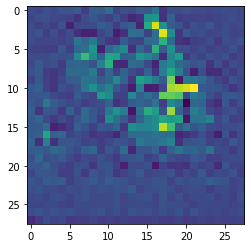

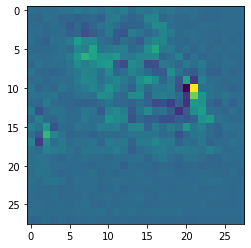

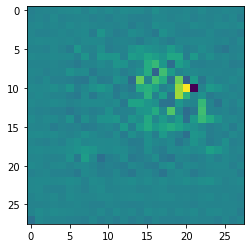

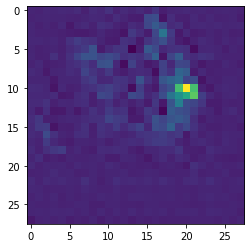

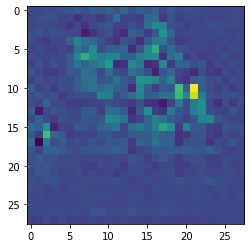

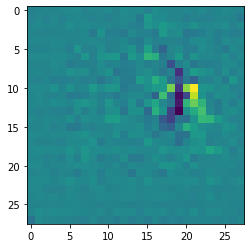

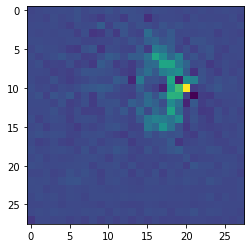

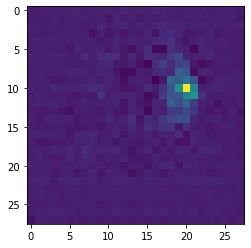

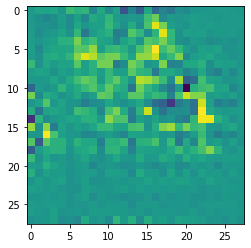

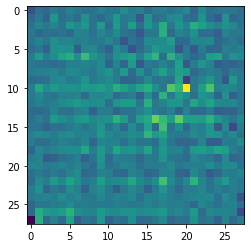

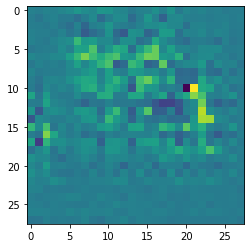

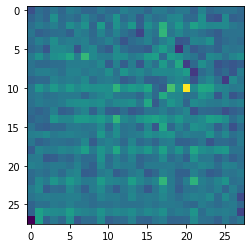

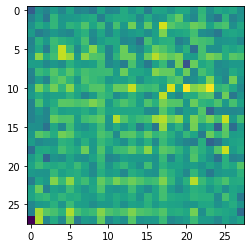

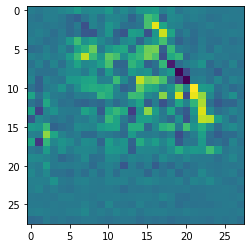

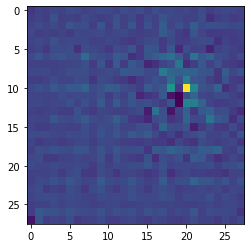

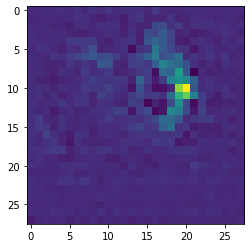

In [38]:
for i in range(batch_size):
    plt.imshow(images.numpy()[i,0,:,:])
    plt.show()

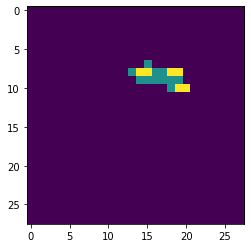

In [39]:
plt.imshow(real_samples.numpy()[0,0,:,:])
plt.show()